# Smart Optimization to Save Computing Time

In [59]:
???

Object `?` not found.


<table style="width:100%; height:90%">
      <tr>
    <th>Grid Search</th>
    <th>Smart Search</th>
  </tr>
  <tr>
    <td><img src="src/07_Table_Optimize BG Default Defaults.png" alt="Optimizing Limits' Parameters" style="width:100%"></td>
    <td><img src="src/08_Table_Smart Optimization.png" alt="Parametrize the Strategy" style="width:100%"></td>
  </tr>
</table>

## Load the model

In [60]:
import pickle

In [61]:
with open('models/model_dt_regression.pkl', 'rb') as f:
    model_dt = pickle.load(f)

In [62]:
model_dt

DecisionTreeRegressor(max_depth=15)

## Load the data

In [63]:
import pandas as pd

df = pd.read_excel('data/Microsoft_LinkedIn_Processed.xlsx', index_col=0, parse_dates=['Date'])
df

,Close,High,Low,Open,Volume,change_tomorrow,change_tomorrow_direction
Date,,,,,,,
2016-12-08,61.009998,61.580002,60.840000,61.299999,21220800,1.549141,UP
2016-12-09,61.970001,61.990002,61.130001,61.180000,27349400,0.321694,UP
2016-12-12,62.169998,62.299999,61.720001,61.820000,20198100,1.286125,UP
2016-12-13,62.980000,63.419998,62.240002,62.500000,35718900,-0.478620,DOWN
2016-12-14,62.680000,63.450001,62.529999,63.000000,30352700,-0.159793,DOWN
...,...,...,...,...,...,...,...
2026-05-14,409.429993,411.839996,400.880005,404.480011,27077500,2.960282,UP
2026-05-15,421.920013,428.170013,412.910004,414.269989,50771200,0.382489,UP
2026-05-18,423.540009,425.119995,415.609985,416.619995,32564100,-1.466148,DOWN


## Parametrize & optimize the investment strategy

### Create Strategy class

In [64]:
from backtesting import Strategy, Backtest

In [65]:
class SimpleRegression(Strategy):
    limit_buy = 1
    limit_sell = -5
    
    def init(self):
        self.model = model_dt
        self.already_bought = False

    def next(self):
        explanatory_today = self.data.df.iloc[[-1], :]
        forecast_tomorrow = self.model.predict(explanatory_today)[0]
        
        if forecast_tomorrow > self.limit_buy and self.already_bought == False:
            self.buy()
            self.already_bought = True
        elif forecast_tomorrow < self.limit_sell and self.already_bought == True:
            self.sell()
            self.already_bought = False
        else:
            pass

### Create `Backtest` class

In [66]:
from backtesting import Backtest

In [67]:
df_explanatory = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [68]:
bt = Backtest(df_explanatory, SimpleRegression,
              cash=10000, commission=.002, exclusive_orders=True)

### Optimize backtesting with multiple combinations

In [69]:
import multiprocessing as mp
mp.set_start_method('fork', force= True)

In [70]:
maximize='Return [%]',

In [71]:
import sys
!{sys.executable} -m pip install scikit-optimize

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [72]:
stats_skopt, heatmap, optimize_result = bt.optimize(
    limit_buy=range(0,10),
    limit_sell=range(-10,0),
    maximize='Return [%]',
    method='skopt',
    max_tries=500,
    random_state=0,
    return_heatmap=True,
    return_optimization=True
)

/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(0), np.int64(-1)] before, using random point [np.int64(5), np.int64(-8)]
  warnings.warn(
/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(0), np.int64(-1)] before, using random point [np.int64(2), np.int64(-3)]
  warnings.warn(
/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(0), np.int64(-1)] before, using random point [np.int64(2), np.int64(-8)]
  warnings.warn(
/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(0), np.int64(-1)] before, using random point [np.int64(1), np.int64(-7)]
  warning

### Which are the best values for the parameters?

In [74]:
print(heatmap.reset_index().columns.tolist())

['limit_buy', 'limit_sell', 'Return [%]']


In [75]:
dff = heatmap.reset_index()
dff = dff.pivot(index='limit_buy', columns='limit_sell', values='Return [%]')
dff

limit_sell,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1
limit_buy,,,,,,,,,,
0,NaN,629.928338,NaN,682.254672,862.433557,NaN,1554.264692,2255.654016,7950.344143,34666.024856
1,642.676719,642.676719,NaN,696.303533,1066.216861,1076.968195,NaN,2208.827877,NaN,7299.991887
2,NaN,NaN,544.634588,NaN,873.679096,NaN,NaN,1674.421635,NaN,264.945529
3,411.782500,411.782500,NaN,403.859357,NaN,NaN,-55.232078,-38.580706,-47.343558,NaN
4,318.440550,NaN,NaN,NaN,NaN,NaN,-42.631902,NaN,-57.494921,NaN
5,318.440550,318.440550,300.771515,NaN,NaN,408.227048,-55.656880,NaN,NaN,-68.872609
6,169.914766,169.914766,157.561042,133.398244,137.607202,NaN,NaN,NaN,-100.000000,-100.000000
7,NaN,212.105241,198.900731,NaN,NaN,295.341588,-100.000000,NaN,NaN,-100.000000
8,194.239517,NaN,-100.000000,NaN,-100.000000,-100.000000,NaN,NaN,NaN,NaN


In [76]:
dff.style.highlight_null(props='background-color: transparent; color: transparent')

limit_sell,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1
limit_buy,,,,,,,,,,
0,nan,629.928338,nan,682.254672,862.433557,nan,1554.264692,2255.654016,7950.344143,34666.024856
1,642.676719,642.676719,nan,696.303533,1066.216861,1076.968195,nan,2208.827877,nan,7299.991887
2,nan,nan,544.634588,nan,873.679096,nan,nan,1674.421635,nan,264.945529
3,411.782500,411.782500,nan,403.859357,nan,nan,-55.232078,-38.580706,-47.343558,nan
4,318.440550,nan,nan,nan,nan,nan,-42.631902,nan,-57.494921,nan
5,318.440550,318.440550,300.771515,nan,nan,408.227048,-55.656880,nan,nan,-68.872609
6,169.914766,169.914766,157.561042,133.398244,137.607202,nan,nan,nan,-100.000000,-100.000000
7,nan,212.105241,198.900731,nan,nan,295.341588,-100.000000,nan,nan,-100.000000
8,194.239517,nan,-100.000000,nan,-100.000000,-100.000000,nan,nan,nan,nan


In [77]:
import numpy as np

In [78]:
dff.sort_index(axis=1,ascending=False)\
  .style.format(precision=0)\
  .background_gradient(vmin=np.nanmin(dff),vmax=np.nanmax(dff))\
  .highlight_null(props='background-color: transparent; color:transparent')

limit_sell,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10
limit_buy,,,,,,,,,,
0,34666,7950,2256,1554,nan,862,682,nan,630,nan
1,7300,nan,2209,nan,1077,1066,696,nan,643,643
2,265,nan,1674,nan,nan,874,nan,545,nan,nan
3,nan,-47,-39,-55,nan,nan,404,nan,412,412
4,nan,-57,nan,-43,nan,nan,nan,nan,nan,318
5,-69,nan,nan,-56,408,nan,nan,301,318,318
6,-100,-100,nan,nan,nan,138,133,158,170,170
7,-100,nan,nan,-100,295,nan,nan,199,212,nan
8,nan,nan,nan,nan,-100,-100,nan,-100,nan,194


### How to interpret smart optimization?

#### Number of evaluations

https://kernc.github.io/backtesting.py/doc/examples/Parameter%20Heatmap%20&%20Optimization.html

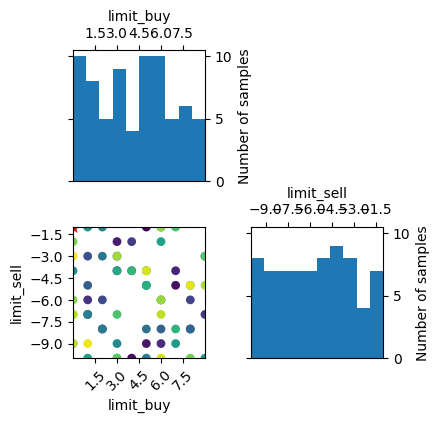

In [79]:
from skopt.plots import plot_evaluations

_ = plot_evaluations(optimize_result, bins=10)

#### Density

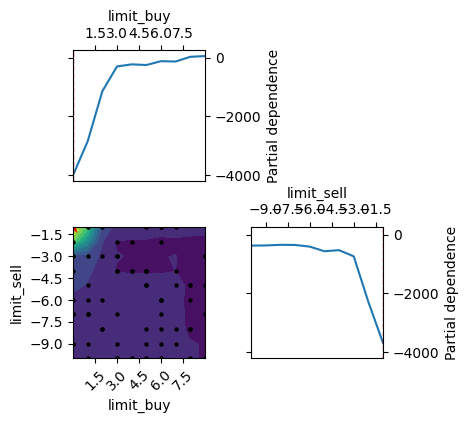

In [80]:
from skopt.plots import plot_objective

_ = plot_objective(optimize_result, n_points=10)

## Practice to master the knowledge

Work on the challenge with another dataset:

1. Learn the <a>mental models</a> to solve the challenge faster.
2. Complete the <a href="08C_Smart Optimization to Save Computing Time.ipynb">notebook</a>.